In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Power and Grid Trend in MW

In [2]:
data = pd.read_excel('sample_data_new.xlsx') # data was sampled minutely
strings_to_match = ['LAR', 'CB']
data = data.drop(columns=[col for col in data.columns if any(s in col for s in strings_to_match)])

data

,TimeStamp,U-LGS1-Active-Power-AI,U-LGS2-Active-Power-AI,U-LGS3_Active-Power-AI,U-LGS1-N75-15-0-AI,U-LGS2-N75-25-0-AI,U-LGS3-N75-35-0-AI
0,05/22/2023 00:00:00,39.58,39.40,0.26,1,1.0,1
1,05/22/2023 00:01:00,39.32,39.31,0.26,1,1.0,1
2,05/22/2023 00:02:00,39.05,39.23,0.26,1,1.0,1
3,05/22/2023 00:03:00,38.79,39.14,0.26,1,1.0,1
4,05/22/2023 00:04:00,40.38,39.06,0.26,1,1.0,1
...,...,...,...,...,...,...,...
5755,05/25/2023 23:55:58,50.04,47.82,0.26,1,1.0,1
5756,05/25/2023 23:56:58,49.96,47.66,0.26,1,1.0,1
5757,05/25/2023 23:57:58,49.89,47.48,0.26,1,1.0,1
5758,05/25/2023 23:58:58,49.81,45.54,0.26,1,1.0,1


In [3]:
# Power trend calculation
data['Power Trend Larona (MW)'] = data['U-LGS1-Active-Power-AI'] + data['U-LGS2-Active-Power-AI'] + data['U-LGS3_Active-Power-AI']  # sum of active power on all units in an area
# data['Power Trend Balambano (MW)'] =
# data['Power Trend Karebe (MW)'] =

# Grid trend calculation
grid_tag_all = ['U-LGS1-N75-15-0-AI', 'U-LGS2-N75-25-0-AI', 'U-LGS3-N75-35-0-AI']               # need to be added from another unit/area
power_tag_all = ['U-LGS1-Active-Power-AI', 'U-LGS2-Active-Power-AI', 'U-LGS3_Active-Power-AI']  # need to be added from another unit/area

for row in data.iterrows():
    aux = 0
    fce = 0

    for gtag, ptag in zip(grid_tag_all, power_tag_all):
        if row[1][gtag] != 0:
            fce += row[1][ptag]
        else:
            aux += row[1][ptag]

    data.loc[row[0], 'Aux Grid Trend'] = aux
    data.loc[row[0], 'Fce Grid Trend'] = fce

data

,TimeStamp,U-LGS1-Active-Power-AI,U-LGS2-Active-Power-AI,U-LGS3_Active-Power-AI,U-LGS1-N75-15-0-AI,U-LGS2-N75-25-0-AI,U-LGS3-N75-35-0-AI,Power Trend Larona (MW),Aux Grid Trend,Fce Grid Trend
0,05/22/2023 00:00:00,39.58,39.40,0.26,1,1.0,1,79.24,0.0,79.24
1,05/22/2023 00:01:00,39.32,39.31,0.26,1,1.0,1,78.89,0.0,78.89
2,05/22/2023 00:02:00,39.05,39.23,0.26,1,1.0,1,78.54,0.0,78.54
3,05/22/2023 00:03:00,38.79,39.14,0.26,1,1.0,1,78.19,0.0,78.19
4,05/22/2023 00:04:00,40.38,39.06,0.26,1,1.0,1,79.70,0.0,79.70
...,...,...,...,...,...,...,...,...,...,...
5755,05/25/2023 23:55:58,50.04,47.82,0.26,1,1.0,1,98.12,0.0,98.12
5756,05/25/2023 23:56:58,49.96,47.66,0.26,1,1.0,1,97.88,0.0,97.88
5757,05/25/2023 23:57:58,49.89,47.48,0.26,1,1.0,1,97.63,0.0,97.63
5758,05/25/2023 23:58:58,49.81,45.54,0.26,1,1.0,1,95.61,0.0,95.61


Classification of operation function (adopting exristing function)

In [4]:
def label_load(row):
    ap = row['Active Power']
    rpm = row['Governor speed actual']
    cb = row['Gen CB Closed'] # tag : U-LGS1-Gen-CB-Closed-DI , default: 1 (plant active), 0 (plant shutdown)

    #if ap < 1 and rpm < 1:
    if cb != 1:
        return 'Shutdown'
    elif ap < 3 and rpm < 90:
        return 'Warming'
    elif ap < 3 and rpm > 90:
        return 'No Load'
    elif 1 <= ap < 20 and rpm > 90:
        return 'Low Load'
    elif 20 <= ap < 40 and rpm > 90:
        return 'Rough Zone'
    elif 40 <= ap < 50 and rpm > 90:
        return 'Part Load'
    elif 50 <= ap < 65 and rpm > 90:
        return 'Efficient Load'
    elif ap >= 65 and rpm > 90:
        return 'High Load'
    else:
        return 'Undefined'

Power Production Formulation : Example for Larona Data

In [5]:
data = pd.read_csv('sample_data.csv') # data was sampled minutely

strings_to_match = ['N75', 'CB', 'LAR']
data = data.drop(columns=[col for col in data.columns if any(s in col for s in strings_to_match)])

data


,TimeStamp,U-LGS1-Active-Power-AI,U-LGS2-Active-Power-AI,U-LGS3_Active-Power-AI
0,01/01/2024 00:00:00,51.63,49.05,50.71
1,01/01/2024 00:01:00,47.76,48.65,49.04
2,01/01/2024 00:02:00,48.87,46.82,49.28
3,01/01/2024 00:03:00,49.98,49.59,50.01
4,01/01/2024 00:04:00,48.06,49.49,47.13
...,...,...,...,...
8635,01/06/2024 23:55:00,50.22,49.46,47.35
8636,01/06/2024 23:56:00,51.01,49.86,47.49
8637,01/06/2024 23:57:00,49.00,49.86,48.49
8638,01/06/2024 23:58:00,50.61,49.86,46.88


In [6]:
# Convert TimeStamp to datetime
data['TimeStamp'] = pd.to_datetime(data['TimeStamp'], format='mixed')

# Group by hour
data['Hour'] = data['TimeStamp'].dt.floor('H')

# Step 1: Calculate average power per hour
hourly_avg = data.groupby('Hour')[['U-LGS1-Active-Power-AI', 'U-LGS2-Active-Power-AI', 'U-LGS3_Active-Power-AI']].mean().reset_index()

# Step 2: Extract date from hourly data
hourly_avg['Date'] = hourly_avg['Hour'].dt.date

# Step 3: Sum the hourly averages per day
daily_avg = hourly_avg.groupby('Date')[['U-LGS1-Active-Power-AI', 'U-LGS2-Active-Power-AI', 'U-LGS3_Active-Power-AI']].sum().reset_index()

daily_avg['Larona Total Power (Sum)'] = np.round(daily_avg['U-LGS1-Active-Power-AI'] + daily_avg['U-LGS2-Active-Power-AI'] + daily_avg['U-LGS3_Active-Power-AI'])

# Step 4: The current day data will be recorded as data for the next day (matching the observation on PI Tag for Power Production)
daily_avg['Date'] = pd.to_datetime(daily_avg['Date']) + pd.Timedelta(days=1)

daily_avg

/tmp/ipykernel_19183/753486935.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['Hour'] = data['TimeStamp'].dt.floor('H')


,Date,U-LGS1-Active-Power-AI,U-LGS2-Active-Power-AI,U-LGS3_Active-Power-AI,Larona Total Power (Sum)
0,2024-01-02,994.993833,1165.657000,1165.677667,3326.0
1,2024-01-03,1157.351833,1144.038667,1138.170000,3440.0
2,2024-01-04,996.134667,986.190833,917.637500,2900.0
3,2024-01-05,892.475000,1128.891000,1027.234167,3049.0
4,2024-01-06,1161.252333,1153.007500,1101.026333,3415.0
5,2024-01-07,1169.712833,1164.804333,1114.422667,3449.0


Active Power and Grid Classification

In [53]:
data = pd.read_csv('sample_data.csv') # data was sampled minutely

strings_to_match = ['LAR', 'LGS2', 'LGS3'] # only select data from LGS#1
data = data.drop(columns=[col for col in data.columns if any(s in col for s in strings_to_match)])

data['TimeStamp'] = pd.to_datetime(data['TimeStamp'], format='mixed')

data


,TimeStamp,U-LGS1-Active-Power-AI,U-LGS1-N75-15-0-AI,U-LGS1-Gen-CB-Closed-DI,U-LGS1-Gen-CB-Open-DI
0,2024-01-01 00:00:00,51.63,1,1,0
1,2024-01-01 00:01:00,47.76,1,1,0
2,2024-01-01 00:02:00,48.87,1,1,0
3,2024-01-01 00:03:00,49.98,1,1,0
4,2024-01-01 00:04:00,48.06,1,1,0
...,...,...,...,...,...
8635,2024-01-06 23:55:00,50.22,1,1,0
8636,2024-01-06 23:56:00,51.01,1,1,0
8637,2024-01-06 23:57:00,49.00,1,1,0
8638,2024-01-06 23:58:00,50.61,1,1,0


In [55]:
conditions = [
        data['U-LGS1-Active-Power-AI'].isna(),
        ((data['U-LGS1-Active-Power-AI'] < 1)),
        ((data['U-LGS1-Active-Power-AI'] < 1)),
        ((data['U-LGS1-Active-Power-AI'] < 1)),
        (data['U-LGS1-Active-Power-AI'] >= 1) & (data['U-LGS1-Active-Power-AI'] < 20), #& ((data['Governor speed actual'] >= 250)),
        (data['U-LGS1-Active-Power-AI'] >= 20) & (data['U-LGS1-Active-Power-AI'] < 40), #& ((data['Governor speed actual'] >= 250)),
        (data['U-LGS1-Active-Power-AI'] >= 40) & (data['U-LGS1-Active-Power-AI'] < 50), #& ((data['Governor speed actual'] >= 250)),
        (data['U-LGS1-Active-Power-AI'] >= 50) & (data['U-LGS1-Active-Power-AI'] < 65), #& ((data['Governor speed actual'] >= 250)),
        (data['U-LGS1-Active-Power-AI'] >= 65)
    ]

choices = ['N/A data', 'Speed No Load', 'Start-Up and Shutdown Process', 'Unit Shut Down', 'Low Load', 'Rough Zone', 'Part Load', 'Best Efficiency Point', 'High Load']
data['Power Class'] = np.select(conditions, choices)

data['Year'] = data['TimeStamp'].dt.year
duration_per_class_per_year = data.groupby(['Year', 'Power Class']).size().unstack(fill_value=0) / 60

data

,TimeStamp,U-LGS1-Active-Power-AI,U-LGS1-N75-15-0-AI,U-LGS1-Gen-CB-Closed-DI,U-LGS1-Gen-CB-Open-DI,Power Class,Year
0,2024-01-01 00:00:00,51.63,1,1,0,Best Efficiency Point,2024
1,2024-01-01 00:01:00,47.76,1,1,0,Part Load,2024
2,2024-01-01 00:02:00,48.87,1,1,0,Part Load,2024
3,2024-01-01 00:03:00,49.98,1,1,0,Part Load,2024
4,2024-01-01 00:04:00,48.06,1,1,0,Part Load,2024
...,...,...,...,...,...,...,...
8635,2024-01-06 23:55:00,50.22,1,1,0,Best Efficiency Point,2024
8636,2024-01-06 23:56:00,51.01,1,1,0,Best Efficiency Point,2024
8637,2024-01-06 23:57:00,49.00,1,1,0,Part Load,2024
8638,2024-01-06 23:58:00,50.61,1,1,0,Best Efficiency Point,2024


In [ ]:
conditions = [
    data['U-LGS1-N75-15-0-AI'].isna(),
    (data['U-LGS1-N75-15-0-AI'] == 1.0),
    (data['U-LGS1-N75-15-0-AI'] != 1.0),
]

choices = ['N/A data', 'FCE Grid', 'Auxiliary Grid']
data['Grid Class'] = np.select(conditions, choices)

data['Year'] = data['TimeStamp'].dt.year
duration_per_class_per_year = data.groupby(['Year', 'Grid Class']).size().unstack(fill_value=0) / 60

data

,TimeStamp,U-LGS1-Active-Power-AI,U-LGS1-N75-15-0-AI,U-LGS1-Gen-CB-Closed-DI,U-LGS1-Gen-CB-Open-DI,Power Class,Year,Grid Class
0,2024-01-01 00:00:00,51.63,1,1,0,Best Efficiency Point,2024,FCE Grid
1,2024-01-01 00:01:00,47.76,1,1,0,Part Load,2024,FCE Grid
2,2024-01-01 00:02:00,48.87,1,1,0,Part Load,2024,FCE Grid
3,2024-01-01 00:03:00,49.98,1,1,0,Part Load,2024,FCE Grid
4,2024-01-01 00:04:00,48.06,1,1,0,Part Load,2024,FCE Grid
...,...,...,...,...,...,...,...,...
8635,2024-01-06 23:55:00,50.22,1,1,0,Best Efficiency Point,2024,FCE Grid
8636,2024-01-06 23:56:00,51.01,1,1,0,Best Efficiency Point,2024,FCE Grid
8637,2024-01-06 23:57:00,49.00,1,1,0,Part Load,2024,FCE Grid
8638,2024-01-06 23:58:00,50.61,1,1,0,Best Efficiency Point,2024,FCE Grid


In [100]:
data['Power Class'].unique()

array(['Best Efficiency Point', 'Part Load', 'Rough Zone', 'Low Load',
       'Speed No Load'], dtype=object)

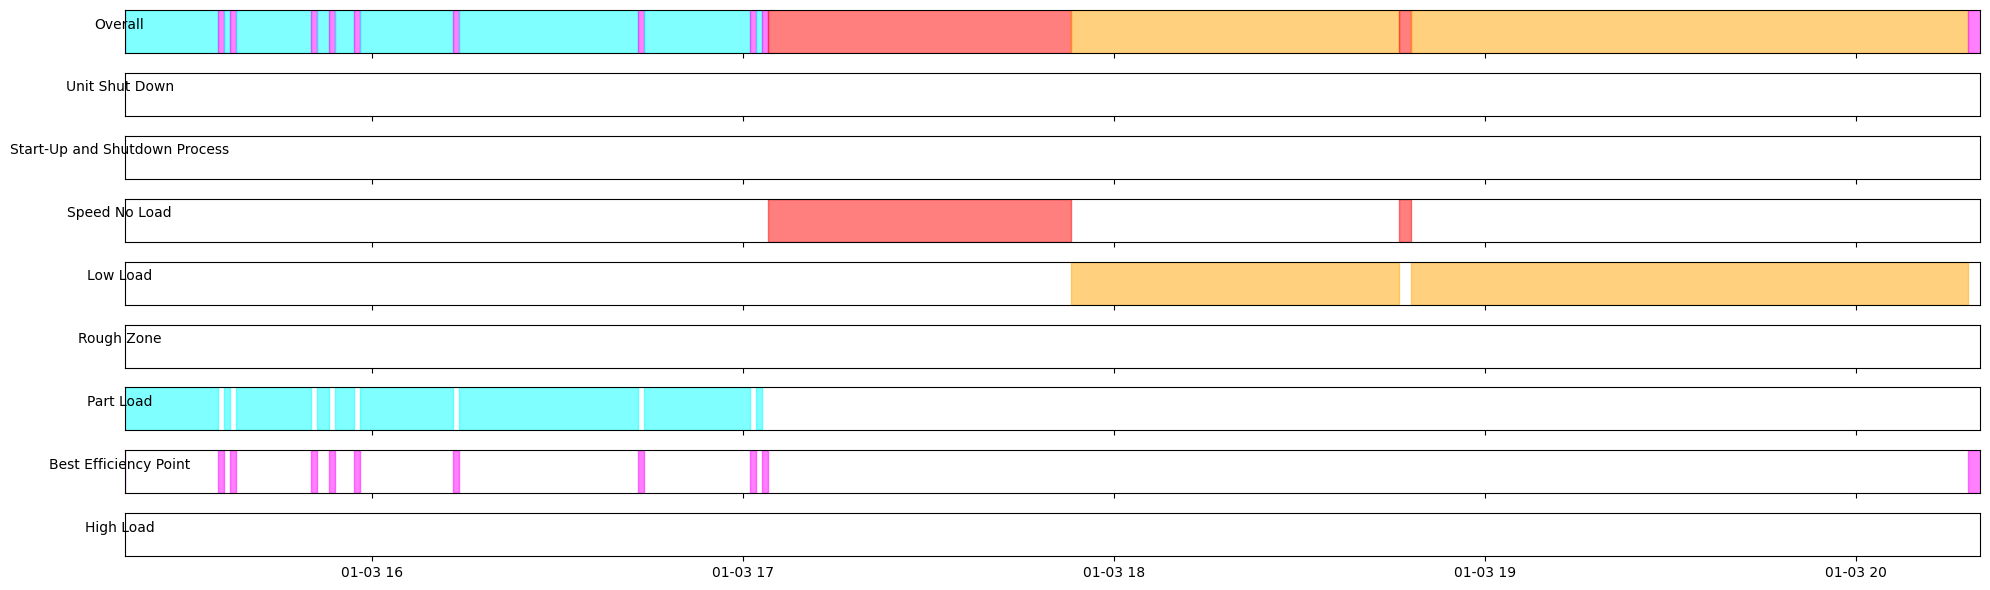

In [117]:
# Creating base directory to save images if it doesn't exist
power_category_colors = {
    'Unit Shut Down': 'yellow',
    #'Starting Up': 'green',
    #'Shutting Down': 'brown',
    'Start-Up and Shutdown Process': 'green',
    'Speed No Load': 'red',
    'Low Load': 'orange',
    'Rough Zone': 'purple',
    'Part Load': 'cyan',
    'Best Efficiency Point': 'magenta',
    'High Load': 'blue',
    #'N/A data': 'black',
    #'0': 'grey'
}

# Function to plot data for a specific month
for week, week_data in data.groupby(data['TimeStamp'].dt.to_period('W')):
    year = week.year
    week_number = week.week

    fig, ax = plt.subplots(9, 1, sharex=True, figsize=(20, 6), gridspec_kw={'height_ratios': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]})

    # Overall
    previous_timestamp = week_data['TimeStamp'].iloc[0]
    previous_category = week_data['Power Class'].iloc[0]

    for current_timestamp, current_category in zip(week_data['TimeStamp'], week_data['Power Class']):
        if current_category != previous_category:
            ax[0].axvspan(previous_timestamp, current_timestamp, color=power_category_colors[previous_category], alpha=0.5)

            previous_timestamp = current_timestamp
            previous_category = current_category

    ax[0].axvspan(previous_timestamp, week_data['TimeStamp'].iloc[-1], color=power_category_colors[previous_category], alpha=0.5)

    ax[0].tick_params(axis='y', which='both', left=False, labelleft=False)
    ax[0].set_ylabel('Overall', rotation=0)

    ax[0].set_xlim([week_data['TimeStamp'].iloc[3800], week_data['TimeStamp'].iloc[4100]])

    # Part Load Only
    for i, cat in enumerate(power_category_colors.keys()):
        in_part_load = False
        start_timestamp = None

        for current_timestamp, current_category in zip(week_data['TimeStamp'], week_data['Power Class']):
            if current_category == cat and not in_part_load:
                # Entering Part Load
                in_part_load = True
                start_timestamp = current_timestamp
            elif current_category != cat and in_part_load:
                # Exiting Part Load
                ax[i+1].axvspan(start_timestamp, current_timestamp, color=power_category_colors[cat], alpha=0.5)
                in_part_load = False

        # If the last entry is still in Part Load
        if in_part_load:
            ax[i+1].axvspan(start_timestamp, week_data['TimeStamp'].iloc[-1], color=power_category_colors[cat], alpha=0.5)

        # Styling
        ax[i+1].tick_params(axis='y', which='both', left=False, labelleft=False)
        ax[i+1].set_ylabel(cat, rotation=0)
        ax[i+1].set_xlim([week_data['TimeStamp'].iloc[3800], week_data['TimeStamp'].iloc[4100]])

    fig.tight_layout()


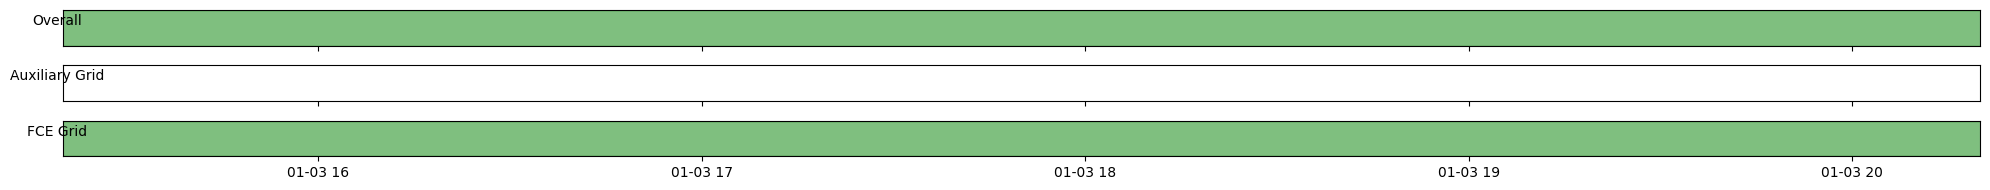

In [118]:
# Creating base directory to save images if it doesn't exist
grid_category_colors = {
    'Auxiliary Grid': 'red',
    'FCE Grid': 'green',
    #'0': 'yellow',
    #'N/A data': 'black'
}

# Function to plot data for a specific month
for week, week_data in data.groupby(data['TimeStamp'].dt.to_period('W')):
    year = week.year
    week_number = week.week

    fig, ax = plt.subplots(3, 1, sharex=True, figsize=(20, 2), gridspec_kw={'height_ratios': [0.1, 0.1, 0.1]})

    # Overall
    previous_timestamp = week_data['TimeStamp'].iloc[0]
    previous_category = week_data['Grid Class'].iloc[0]

    for current_timestamp, current_category in zip(week_data['TimeStamp'], week_data['Grid Class']):
        if current_category != previous_category:
            ax[0].axvspan(previous_timestamp, current_timestamp, color=power_category_colors[previous_category], alpha=0.5)

            previous_timestamp = current_timestamp
            previous_category = current_category

    ax[0].axvspan(previous_timestamp, week_data['TimeStamp'].iloc[-1], color=grid_category_colors[previous_category], alpha=0.5)

    ax[0].tick_params(axis='y', which='both', left=False, labelleft=False)
    ax[0].set_ylabel('Overall', rotation=0)

    ax[0].set_xlim([week_data['TimeStamp'].iloc[3800], week_data['TimeStamp'].iloc[4100]])

    # Part Load Only
    for i, cat in enumerate(grid_category_colors.keys()):
        in_part_load = False
        start_timestamp = None

        for current_timestamp, current_category in zip(week_data['TimeStamp'], week_data['Grid Class']):
            if current_category == cat and not in_part_load:
                # Entering Part Load
                in_part_load = True
                start_timestamp = current_timestamp
            elif current_category != cat and in_part_load:
                # Exiting Part Load
                ax[i+1].axvspan(start_timestamp, current_timestamp, color=grid_category_colors[cat], alpha=0.5)
                in_part_load = False

        # If the last entry is still in Part Load
        if in_part_load:
            ax[i+1].axvspan(start_timestamp, week_data['TimeStamp'].iloc[-1], color=grid_category_colors[cat], alpha=0.5)

        # Styling
        ax[i+1].tick_params(axis='y', which='both', left=False, labelleft=False)
        ax[i+1].set_ylabel(cat, rotation=0)
        ax[i+1].set_xlim([week_data['TimeStamp'].iloc[3800], week_data['TimeStamp'].iloc[4100]])

    fig.tight_layout()


In [104]:
for cat in power_category_colors.keys():
    print(cat)

Unit Shut Down
Start-Up and Shutdown Process
Speed No Load
Low Load
Rough Zone
Part Load
Best Efficiency Point
High Load
N/A data
0


In [66]:
week_data

,TimeStamp,U-LGS1-Active-Power-AI,U-LGS1-N75-15-0-AI,U-LGS1-Gen-CB-Closed-DI,U-LGS1-Gen-CB-Open-DI,Power Class,Year,Grid Class
0,2024-01-01 00:00:00,51.63,1,1,0,Best Efficiency Point,2024,FCE Grid
1,2024-01-01 00:01:00,47.76,1,1,0,Part Load,2024,FCE Grid
2,2024-01-01 00:02:00,48.87,1,1,0,Part Load,2024,FCE Grid
3,2024-01-01 00:03:00,49.98,1,1,0,Part Load,2024,FCE Grid
4,2024-01-01 00:04:00,48.06,1,1,0,Part Load,2024,FCE Grid
...,...,...,...,...,...,...,...,...
8635,2024-01-06 23:55:00,50.22,1,1,0,Best Efficiency Point,2024,FCE Grid
8636,2024-01-06 23:56:00,51.01,1,1,0,Best Efficiency Point,2024,FCE Grid
8637,2024-01-06 23:57:00,49.00,1,1,0,Part Load,2024,FCE Grid
8638,2024-01-06 23:58:00,50.61,1,1,0,Best Efficiency Point,2024,FCE Grid
